# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1037s 6us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

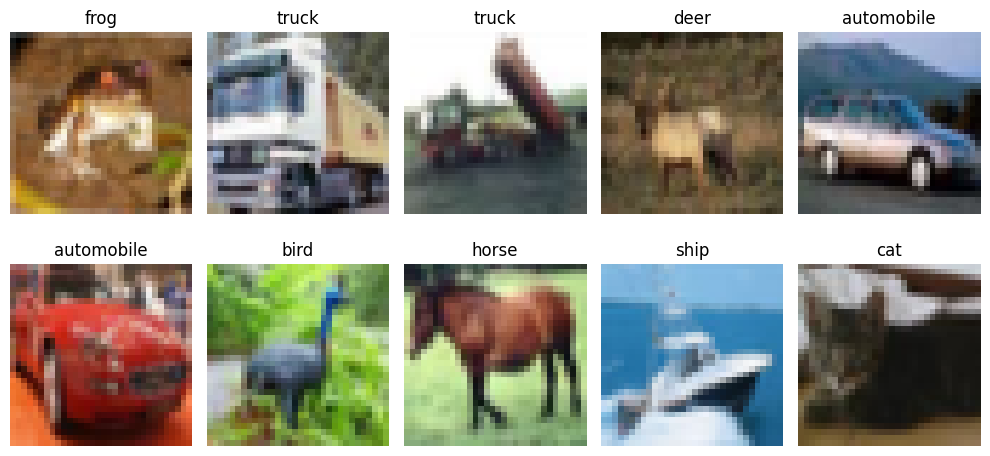

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.2649 - loss: 2.0100 - val_accuracy: 0.3442 - val_loss: 1.8324
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3060 - loss: 1.8849 - val_accuracy: 0.3594 - val_loss: 1.7734
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3293 - loss: 1.8361 - val_accuracy: 0.3730 - val_loss: 1.7883
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3432 - loss: 1.8038 - val_accuracy: 0.3994 - val_loss: 1.7143
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3538 - loss: 1.7791 - val_accuracy: 0.3868 - val_loss: 1.7441
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3589 - loss: 1.7603 - val_accuracy: 0.3994 - val_loss: 1.7069
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3698 - loss: 1.7379 - val_accuracy: 0.4006 - val_loss: 1.7206
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3756 - loss: 1.7224 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4217 - loss: 1.6402
ANN Test Accuracy: 0.42170000076293945


In [7]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("ANN_Deep Test Accuracy:", ann_deep_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.3194 - loss: 1.8942 - val_accuracy: 0.3498 - val_loss: 1.7757
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.3809 - loss: 1.7222 - val_accuracy: 0.3254 - val_loss: 1.8229
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.4006 - loss: 1.6702 - val_accuracy: 0.4034 - val_loss: 1.6410
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.4128 - loss: 1.6404 - val_accuracy: 0.3896 - val_loss: 1.6960
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.4142 - loss: 1.6298 - val_accuracy: 0.4360 - val_loss: 1.5817
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.4207 - loss: 1.6161 - val_accuracy: 0.4298 - val_loss: 1.5857
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.4298 - loss: 1.5950 - val_accuracy: 0.3928 - val_loss: 1.6727
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.4340 - loss: 1.5787 - 

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 119ms/step - accuracy: 0.4685 - loss: 1.4921 - val_accuracy: 0.5526 - val_loss: 1.2556
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 111ms/step - accuracy: 0.6071 - loss: 1.1234 - val_accuracy: 0.5530 - val_loss: 1.3605
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6643 - loss: 0.9632 - val_accuracy: 0.6208 - val_loss: 1.1030
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7074 - loss: 0.8348 - val_accuracy: 0.6840 - val_loss: 0.9045
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7372 - loss: 0.7439 - val_accuracy: 0.6326 - val_loss: 1.1112
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 121ms/step - accuracy: 0.7653 - loss: 0.6612 - val_accuracy: 0.6792 - val_loss: 1.0239
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7915 - loss: 0.5877 - val_accuracy: 0.6986 - val_loss: 0.9263
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.8097 - loss:

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7188 - loss: 0.9181
CNN Test Accuracy: 0.7188000082969666


## 📈 Compare Learning Curves

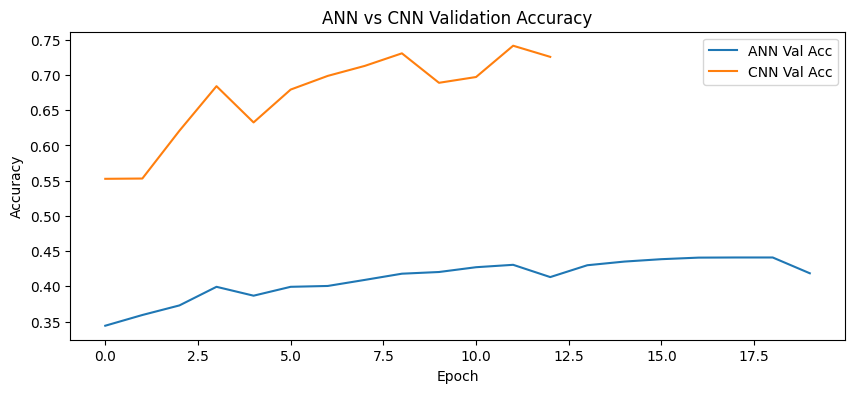

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=3,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN_Augmented Test Accuracy:", aug_test_acc)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.3536 - loss: 1.7721 - val_accuracy: 0.4980 - val_loss: 1.3906
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.4558 - loss: 1.5047 - val_accuracy: 0.5462 - val_loss: 1.2750
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.4975 - loss: 1.4019 - val_accuracy: 0.5718 - val_loss: 1.2029
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5687 - loss: 1.2044
CNN_Augmented Test Accuracy: 0.5687000155448914


# 📊 Final Comparison Table

In [15]:
comparison = pd.DataFrame({
    "Model": ["ANN", "ANN_Deep", "CNN", "CNN_Augmented"],
    "Test Accuracy": [ann_test_acc, ann_deep_test_acc, cnn_test_acc, aug_test_acc]
}).sort_values("Test Accuracy", ascending=False)
comparison

,Model,Test Accuracy
2,CNN,0.7188
3,CNN_Augmented,0.5687
1,ANN_Deep,0.4600
0,ANN,0.4217


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**